# HOUSE PRICE DATASET

#### Loading all the libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_log_error

In [26]:
data = pd.read_csv("housing_dataset.csv")

In [27]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### Converting all yes/no into 1/0

In [28]:
col = ["mainroad",	"guestroom",	"basement",	"hotwaterheating",	"airconditioning", "prefarea"]
for i in col:
    data[i] = data[i].map({"yes": 1, "no": 0})

#### Distributing furnishingstatus column into 3 columns names: ["furnished", "semi-furnished", "unfurnished"]

In [29]:
cat_encoder = OneHotEncoder(sparse_output=False)
status = data[["furnishingstatus"]]
housing_cat_hot = cat_encoder.fit_transform(status)
housing_cat_hot

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]], shape=(545, 3))

In [30]:
housing_cat_hot = pd.DataFrame(housing_cat_hot, columns=["furnished", "semi-furnished", "unfurnished"], index=status.index)

In [31]:
housing_cat_hot

,furnished,semi-furnished,unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
540,0.0,0.0,1.0
541,0.0,1.0,0.0
542,0.0,0.0,1.0
543,1.0,0.0,0.0


In [32]:
data = pd.concat([data, housing_cat_hot], axis=1)
data = data.drop("furnishingstatus", axis=1)
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1.0,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1.0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0.0,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1.0,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0,0.0,1.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0.0,1.0,0.0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0,0.0,1.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1.0,0.0,0.0


## Creating train test set (Stratified shuffling)

In [33]:
# Create price categories
data["price_cat"] = pd.cut(data["price"],
                             bins=[0, 2000000, 4000000, 6000000, 8000000, 10000000, np.inf],
                             labels=[1,2, 3, 4, 5, 6])

In [34]:
# Assume price_cat is a column in the dataset created from price
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data, data["price_cat"]):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

### Checking Shufflinng

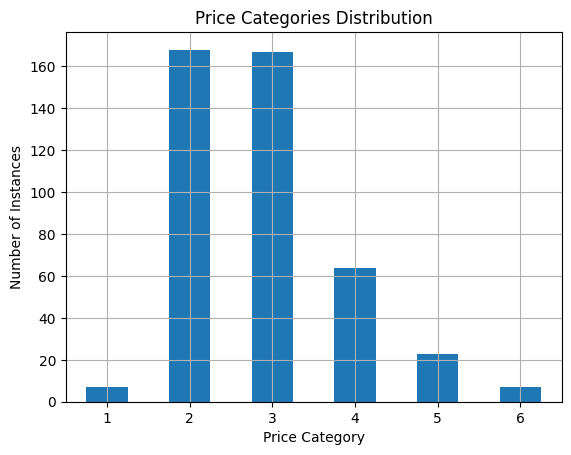

In [35]:
strat_train_set["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Price Categories Distribution")
plt.xlabel("Price Category")
plt.ylabel("Number of Instances")
plt.show()

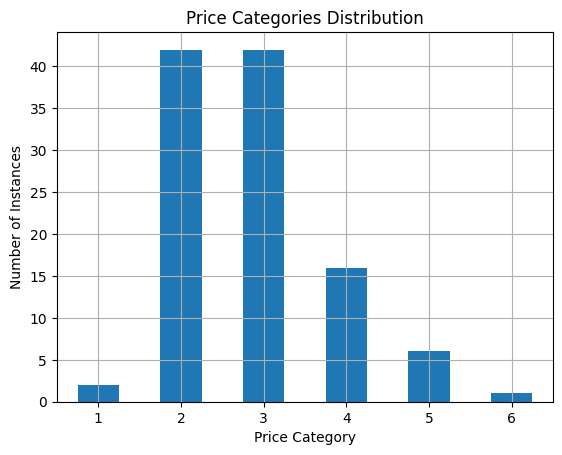

In [36]:
strat_test_set["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Price Categories Distribution")
plt.xlabel("Price Category")
plt.ylabel("Number of Instances")
plt.show()

## checking correlation between all columns

In [37]:
corr_matrix = data.corr()
corr_matrix["price"].sort_values(ascending=False)
# we can see that price_cat is most correlated with the price 

price              1.000000
price_cat          0.952103
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
mainroad           0.296898
guestroom          0.255517
furnished          0.229350
basement           0.187057
hotwaterheating    0.093073
semi-furnished     0.063656
unfurnished       -0.280587
Name: price, dtype: float64

## Splitting features and target

In [38]:
target = strat_train_set["price"].copy()
features = strat_train_set.drop("price", axis=1)

In [39]:
target_test_set = strat_test_set["price"].copy()
features_test_set = strat_test_set.drop("price", axis=1)

## Standard Scaling

In [40]:
std_scalar = StandardScaler()
features_std_scalar = std_scalar.fit_transform(features)

In [41]:
std_scalar = StandardScaler()
features_std_scalar_test_set = std_scalar.fit_transform(features_test_set)

## Training Model by LinearRegression, DecisionTreeRegressor, RandomForestRegressor

In [42]:
lin_reg = LinearRegression()
lin_reg.fit(features_std_scalar, target)
lin_preds = lin_reg.predict(features_std_scalar)
lin_rmse = root_mean_squared_error(target, lin_preds)
print("Linear Regression RMSE:", lin_rmse)

Linear Regression RMSE: 521260.1032407045


In [43]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(features_std_scalar, target)
tree_preds = tree_reg.predict(features_std_scalar)
tree_rmse = root_mean_squared_error(target, tree_preds)
print("Decision Tree Regressor:", tree_rmse)

Decision Tree Regressor: 24959.00308230249


In [44]:
forest_reg = RandomForestRegressor()
forest_reg.fit(features_std_scalar, target)
forest_preds = forest_reg.predict(features_std_scalar)
forest_rmse = root_mean_squared_error(target, forest_preds)
print("Random forest Regressor:", forest_rmse)

Random forest Regressor: 193644.60265896784


## Cross-Validation: A Better Evaluation Strategy

#### by Linear Regressor

In [45]:
from sklearn.model_selection import cross_val_score
lin_rmses =-cross_val_score(
    lin_reg,
    features_std_scalar,
    target,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("Linear Regression CV RMSEs:", lin_rmses)
print("\nCross-Validation Performance (Linear Regression):")
print(pd.Series(lin_rmses).describe())

Linear Regression CV RMSEs: [472732.02762051 706231.64010123 513708.93871032 509882.35914638
 570724.66887995 494583.68850495 526361.42124436 526166.46138522
 613178.77715554 481256.26297013]

Cross-Validation Performance (Linear Regression):
count        10.000000
mean     541482.624572
std       71433.133482
min      472732.027621
25%      498408.356165
50%      519937.700048
75%      559633.856971
max      706231.640101
dtype: float64


#### by Decision Tree Regressor

In [46]:
tree_rmses =-cross_val_score(
    tree_reg,
    features_std_scalar,
    target,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("Decision tree CV RMSEs:", tree_rmses)
print("\nCross-Validation Performance (Decision tree):")
print(pd.Series(tree_rmses).describe())

Decision tree CV RMSEs: [699988.86354778 712635.70079351 658410.08135301 693352.84291097
 685856.31612141 591923.46561674 657944.79605143 568412.36203478
 727328.44190868 710559.9413368 ]

Cross-Validation Performance (Decision tree):
count        10.000000
mean     670641.281168
std       52848.953732
min      568412.362035
25%      658061.117377
50%      689604.579516
75%      707917.171890
max      727328.441909
dtype: float64


#### Random Forest Regressor

In [47]:
forest_rmses =-cross_val_score(
    forest_reg,
    features_std_scalar,
    target,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("Random Forest CV RMSEs:", forest_rmses)
print("\nCross-Validation Performance (Random Forest):")
print(pd.Series(forest_rmses).describe())

Random Forest CV RMSEs: [458310.76657339 622173.38334478 521459.83100443 522563.20922714
 519031.77431049 456014.09979425 522776.56206776 487057.52444362
 544334.05430273 503168.87597716]

Cross-Validation Performance (Random Forest):
count        10.000000
mean     515689.008105
std       47294.935406
min      456014.099794
25%      491085.362327
50%      520245.802657
75%      522723.223858
max      622173.383345
dtype: float64


## Now predicting on test set by Random Forest

In [48]:
pred = forest_reg.predict(features_std_scalar_test_set)
forest_rms = root_mean_squared_error(target_test_set, pred)
mae = mean_absolute_error(target_test_set, pred)
msle = mean_squared_log_error(target_test_set, pred)

print("Root Mean Squared Error:", forest_rms)
print("Mean Absolute Error:", mae)
print("Mean Squared Log Error:", msle)

Root Mean Squared Error: 490876.8119862206
Mean Absolute Error: 391432.5290519878
Mean Squared Log Error: 0.01594873148820491
